In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from scipy.sparse import hstack

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("model_saved", exist_ok=True)
os.makedirs("figures", exist_ok=True)
print("CELL 1 (E-Commerce): Sẵn sàng.")

CELL 1 (E-Commerce): Sẵn sàng.


Kích thước tập dữ liệu E-Commerce: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses



Phân bố biến mục tiêu Recommended IND:
Recommended IND
1    19314
0     4172
Name: count, dtype: int64

Tỷ lệ:
Recommended IND
1    0.822362
0    0.177638
Name: proportion, dtype: float64


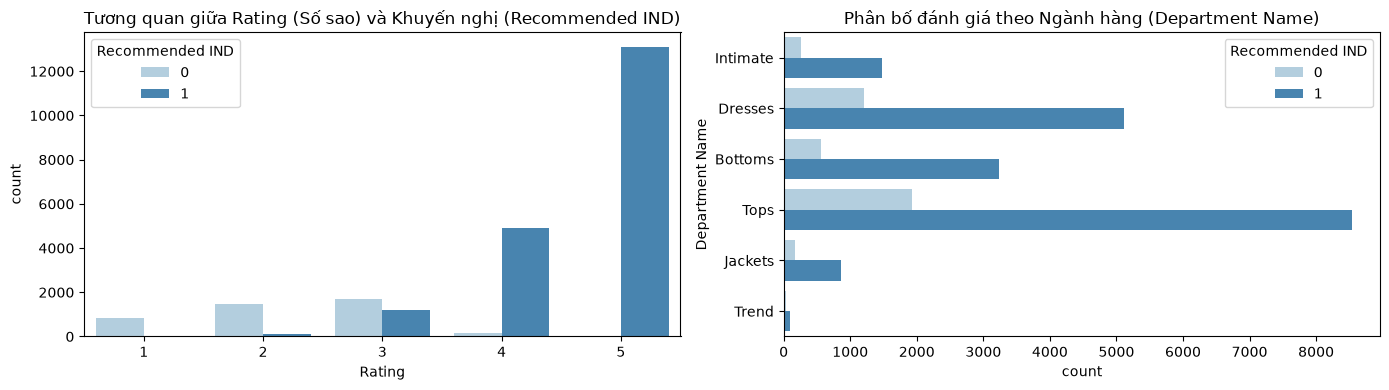

In [2]:
df_cloth = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
print("Kích thước tập dữ liệu E-Commerce:", df_cloth.shape)
display(df_cloth.head(3))

print("\nPhân bố biến mục tiêu Recommended IND:")
print(df_cloth['Recommended IND'].value_counts())
print("\nTỷ lệ:")
print(df_cloth['Recommended IND'].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df_cloth, x='Rating', hue='Recommended IND', ax=ax[0], palette='Blues')
ax[0].set_title("Tương quan giữa Rating (Số sao) và Khuyến nghị (Recommended IND)")

sns.countplot(data=df_cloth, y='Department Name', hue='Recommended IND', ax=ax[1], palette='Blues')
ax[1].set_title("Phân bố đánh giá theo Ngành hàng (Department Name)")
plt.tight_layout()
plt.savefig("figures/fig_4_1_eda_clothing.png", dpi=300)
plt.show()

In [3]:
# 1. Làm sạch và gộp văn bản Title + Review Text
df_cloth['Title'] = df_cloth['Title'].fillna('')
df_cloth['Review Text'] = df_cloth['Review Text'].fillna('')
df_cloth['review_combined'] = (df_cloth['Title'] + " " + df_cloth['Review Text']).str.strip()

numeric_cols = ['Age', 'Rating', 'Positive Feedback Count']
categorical_cols = ['Division Name', 'Department Name', 'Class Name']

# 2. Chia tập Train (70%), Val (15%), Test (15%) phân tầng
df_train, df_temp = train_test_split(df_cloth, test_size=0.30, random_state=SEED, stratify=df_cloth['Recommended IND'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['Recommended IND'])

# 3. Vector hóa TF-IDF trên tập Text (fit CHỈ trên train)
tfidf = TfidfVectorizer(max_features=2500, ngram_range=(1, 2), stop_words='english')
X_tr_text = tfidf.fit_transform(df_train['review_combined'])
X_va_text = tfidf.transform(df_val['review_combined'])
X_te_text = tfidf.transform(df_test['review_combined'])

# 4. Xử lý dữ liệu bảng (Tabular)
tab_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
    ]), categorical_cols)
])

X_tr_tab = tab_preprocessor.fit_transform(df_train[numeric_cols + categorical_cols])
X_va_tab = tab_preprocessor.transform(df_val[numeric_cols + categorical_cols])
X_te_tab = tab_preprocessor.transform(df_test[numeric_cols + categorical_cols])

# 5. Ghép nối (Early Fusion): Tabular + Text -> Vector d chiều
X_train_f = hstack([X_tr_tab, X_tr_text]).tocsr()
X_val_f = hstack([X_va_tab, X_va_text]).tocsr()
X_test_f = hstack([X_te_tab, X_te_text]).tocsr()

y_train_c = df_train['Recommended IND'].values
y_val_c = df_val['Recommended IND'].values
y_test_c = df_test['Recommended IND'].values

print(f"Tổng số chiều vector sau khi dung hợp (Tabular + TF-IDF): {X_train_f.shape[1]}")
print(f"Train size: {X_train_f.shape[0]} | Val size: {X_val_f.shape[0]} | Test size: {X_test_f.shape[0]}")

Tổng số chiều vector sau khi dung hợp (Tabular + TF-IDF): 2535
Train size: 16440 | Val size: 3523 | Test size: 3523


In [4]:
ml_cloth_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=SEED, n_jobs=-1)
}

cloth_ml_results = []
for name, model in ml_cloth_models.items():
    model.fit(X_train_f, y_train_c)
    preds = model.predict(X_test_f)
    probs = model.predict_proba(X_test_f)[:, 1]
    cloth_ml_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, preds),
        "Precision": precision_score(y_test_c, preds),
        "Recall": recall_score(y_test_c, preds),
        "F1": f1_score(y_test_c, preds),
        "ROC-AUC": roc_auc_score(y_test_c, probs)
    })

df_cloth_ml = pd.DataFrame(cloth_ml_results)
print("BẢNG KẾT QUẢ ML TRÊN DỮ LIỆU ĐA PHƯƠNG THỨC:")
display(df_cloth_ml)

BẢNG KẾT QUẢ ML TRÊN DỮ LIỆU ĐA PHƯƠNG THỨC:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.944366,0.962976,0.969624,0.966288,0.979769
1,Random Forest,0.851263,0.849485,0.995513,0.916720,0.970791


In [5]:
# Kiến trúc 5 tầng: Input(2534) -> 128 -> 64 -> 32 -> 16 -> Output(2)
class MultimodalMLP5(nn.Module):
    def __init__(self, in_features, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2), # Điều chuẩn chống quá khớp khi vector từ thưa
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )
    def forward(self, x):
        return self.net(x)

in_cloth_dim = X_train_f.shape[1]
multimodal_model = MultimodalMLP5(in_features=in_cloth_dim, num_classes=2)
print(multimodal_model)
print(f"\nTổng số tham số mạng Multimodal: {sum(p.numel() for p in multimodal_model.parameters()):,}")

MultimodalMLP5(
  (net): Sequential(
    (0): Linear(in_features=2535, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=2, bias=True)
  )
)

Tổng số tham số mạng Multimodal: 335,506


In [6]:
# Helper chuyển Sparse Matrix sang DataLoader Dense theo từng batch để tiết kiệm RAM
def create_sparse_loader(X_sp, y_arr, batch_size=64, shuffle=True):
    dataset = TensorDataset(torch.tensor(X_sp.toarray(), dtype=torch.float32), 
                            torch.tensor(y_arr, dtype=torch.long))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

cloth_train_loader = create_sparse_loader(X_train_f, y_train_c, batch_size=64, shuffle=True)
criterion_cloth = nn.CrossEntropyLoss()
optimizer_cloth = optim.Adam(multimodal_model.parameters(), lr=0.001)

epochs_cloth = 15
history_cloth = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# Chuẩn bị trước tập validation tensor
X_val_dense = torch.tensor(X_val_f.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_c, dtype=torch.long)

for epoch in range(1, epochs_cloth + 1):
    multimodal_model.train()
    running_loss, correct_train = 0.0, 0
    for xb, yb in cloth_train_loader:
        optimizer_cloth.zero_grad()
        logits = multimodal_model(xb)
        loss = criterion_cloth(logits, yb)
        loss.backward()
        optimizer_cloth.step()
        running_loss += loss.item() * len(yb)
        correct_train += (logits.argmax(1) == yb).sum().item()
        
    multimodal_model.eval()
    with torch.no_grad():
        v_logits = multimodal_model(X_val_dense)
        v_loss = criterion_cloth(v_logits, y_val_tensor).item()
        v_acc = (v_logits.argmax(1) == y_val_tensor).float().mean().item()
        
    history_cloth['train_loss'].append(running_loss / X_train_f.shape[0])
    history_cloth['val_loss'].append(v_loss)
    history_cloth['train_acc'].append(correct_train / X_train_f.shape[0])
    history_cloth['val_acc'].append(v_acc)
    
    print(f"Epoch {epoch:02d}/{epochs_cloth} | Train Loss: {history_cloth['train_loss'][-1]:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")

Epoch 01/15 | Train Loss: 0.2505 | Val Loss: 0.1366 | Val Acc: 0.9446
Epoch 02/15 | Train Loss: 0.1173 | Val Loss: 0.1323 | Val Acc: 0.9446
Epoch 03/15 | Train Loss: 0.0988 | Val Loss: 0.1425 | Val Acc: 0.9412
Epoch 04/15 | Train Loss: 0.0820 | Val Loss: 0.1678 | Val Acc: 0.9350
Epoch 05/15 | Train Loss: 0.0623 | Val Loss: 0.1888 | Val Acc: 0.9378
Epoch 06/15 | Train Loss: 0.0427 | Val Loss: 0.2285 | Val Acc: 0.9339
Epoch 07/15 | Train Loss: 0.0285 | Val Loss: 0.3426 | Val Acc: 0.9341
Epoch 08/15 | Train Loss: 0.0191 | Val Loss: 0.4069 | Val Acc: 0.9336
Epoch 09/15 | Train Loss: 0.0156 | Val Loss: 0.4123 | Val Acc: 0.9347
Epoch 10/15 | Train Loss: 0.0111 | Val Loss: 0.4998 | Val Acc: 0.9324
Epoch 11/15 | Train Loss: 0.0123 | Val Loss: 0.4113 | Val Acc: 0.9359
Epoch 12/15 | Train Loss: 0.0098 | Val Loss: 0.4363 | Val Acc: 0.9364
Epoch 13/15 | Train Loss: 0.0072 | Val Loss: 0.5063 | Val Acc: 0.9350
Epoch 14/15 | Train Loss: 0.0068 | Val Loss: 0.4993 | Val Acc: 0.9330
Epoch 15/15 | Train 

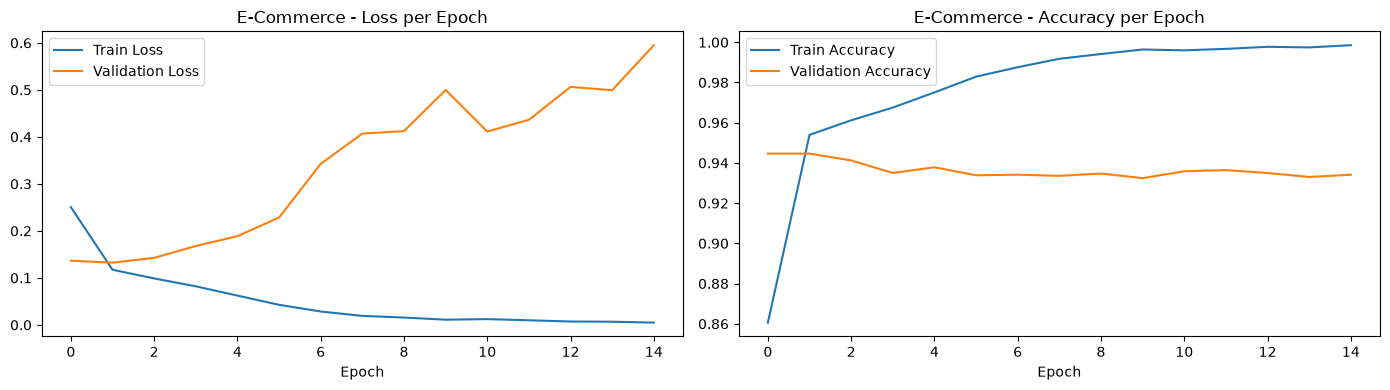

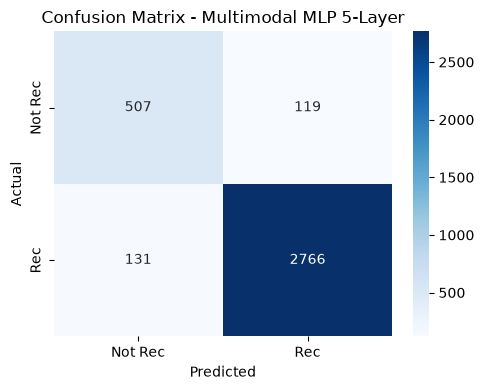


BẢNG ĐỐI SÁNH HIỆU NĂNG E-COMMERCE TỔNG HỢP (TEST SET):


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.944366,0.962976,0.969624,0.966288,0.979769
1,Random Forest,0.851263,0.849485,0.995513,0.916720,0.970791
2,Deep Learning 5-Layer,0.929038,0.958752,0.954781,0.956762,0.963737


CELL 7 (E-Commerce): Đã hoàn thành lưu trữ toàn bộ mô hình.


In [7]:
# Dự đoán trên tập Test độc lập
X_test_dense = torch.tensor(X_test_f.toarray(), dtype=torch.float32)
multimodal_model.eval()
with torch.no_grad():
    t_logits = multimodal_model(X_test_dense)
    t_probs = torch.softmax(t_logits, dim=1)[:, 1].numpy()
    t_preds = t_logits.argmax(dim=1).numpy()

# 1. Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_cloth['train_loss'], label='Train Loss')
ax1.plot(history_cloth['val_loss'], label='Validation Loss')
ax1.set_title("E-Commerce - Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history_cloth['train_acc'], label='Train Accuracy')
ax2.plot(history_cloth['val_acc'], label='Validation Accuracy')
ax2.set_title("E-Commerce - Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.savefig("figures/fig_4_9_learning_curves_clothing.png", dpi=300)
plt.show()

# 2. Confusion Matrix
cm_cloth = confusion_matrix(y_test_c, t_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_cloth, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Rec', 'Rec'], yticklabels=['Not Rec', 'Rec'])
plt.title("Confusion Matrix - Multimodal MLP 5-Layer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("figures/fig_4_10_confusion_matrix_clothing.png", dpi=300)
plt.show()

# Bảng so sánh tổng hợp
dl_cloth_res = {
    "Model": "Deep Learning 5-Layer",
    "Accuracy": accuracy_score(y_test_c, t_preds),
    "Precision": precision_score(y_test_c, t_preds),
    "Recall": recall_score(y_test_c, t_preds),
    "F1": f1_score(y_test_c, t_preds),
    "ROC-AUC": roc_auc_score(y_test_c, t_probs)
}
final_cloth_comparison = pd.concat([df_cloth_ml, pd.DataFrame([dl_cloth_res])], ignore_index=True)
print("\nBẢNG ĐỐI SÁNH HIỆU NĂNG E-COMMERCE TỔNG HỢP (TEST SET):")
display(final_cloth_comparison)

# Lưu trữ artifacts
joblib.dump(tfidf, "model_saved/clothing_tfidf.joblib")
joblib.dump(tab_preprocessor, "model_saved/clothing_tab_preprocessor.joblib")
torch.save(multimodal_model.state_dict(), "model_saved/clothing_mlp5.pth")
print("CELL 7 (E-Commerce): Đã hoàn thành lưu trữ toàn bộ mô hình.")